In [48]:
import sys
import os
import cv2
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
import glob
import random
from pathlib import Path

In [2]:
import torch
from torch import nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.12.1+cu130'

In [3]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

1. Configure Base Paths

In [4]:
ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

print(ROOT_DIR)

/home/samuel-linux/master-degree-project


In [5]:
DATA_PATH = ROOT_DIR / "data" / "UCF_Crime" / "raw"
DATA_PATH

PosixPath('/home/samuel-linux/master-degree-project/data/UCF_Crime/raw')

In [6]:
class_names = os.listdir(DATA_PATH)
class_names

['RoadAccidents',
 'Assault',
 'Arrest',
 'Arson',
 'Shooting',
 'Stealing',
 'Burglary',
 'Robbery',
 'Shoplifting',
 'Fighting',
 'Abuse',
 'Explosion',
 'Vandalism']

In [35]:
videos_path = DATA_PATH / class_names[2]
videos = list(videos_path.glob("*.mp4"))[0]
videos

PosixPath('/home/samuel-linux/master-degree-project/data/UCF_Crime/raw/Arrest/Arrest017_x264.mp4')

2. Explore Dataset

In [61]:
def dataset_frames_labels(dataset_path: Path, rand_num: int):
  frames = []
  labels = []
  
  classes_names = os.listdir(dataset_path)
  
  for class_name in classes_names:
    videos_path = dataset_path / class_name
    video_path = list(videos_path.glob("*.mp4"))[rand_num]
  
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
      print("Error: Could not open the video file.")
      return
      
    ret, frame = cap.read()
    
    if not ret:
      break
    
    frames.append(frame)
    labels.append(video_path.name)
    
  return frames, labels
        
        

In [69]:
rand_num = random.randint(10, 50)

frames, labels = dataset_frames_labels(dataset_path=DATA_PATH, rand_num=rand_num) # type: ignore

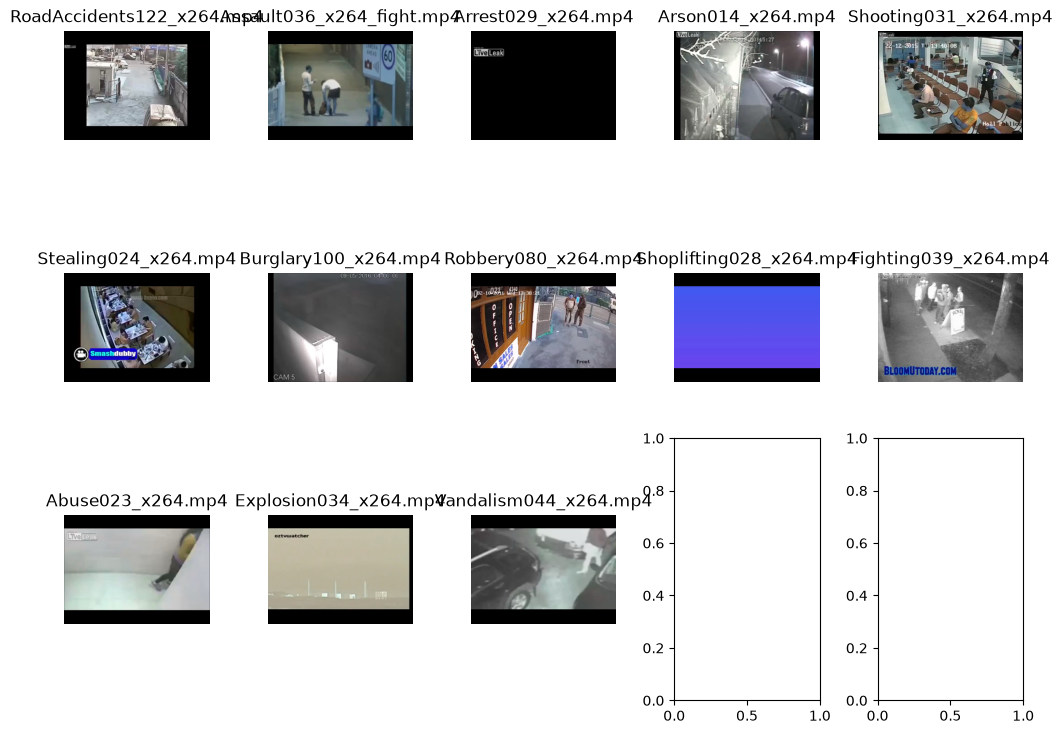

In [70]:
fig, axes = plt.subplots(3, 5, figsize=(10, 8))

for ax, frame, label in zip(axes.flatten(), frames, labels):
  ax.imshow(frame)
  ax.set_title(label)
  ax.axis("off")

plt.tight_layout()
plt.show()